<h1 style="font-size:96px; margin:0;">Research Question</h1>

What team performance factors are associated with an NBA team making the playoffs?

This project examines which NBA team performance factors are associated with making the playoffs. The analysis uses team statistics such as winning percentage, point differential, points scored, and points allowed. By comparing teams that made the playoffs with teams that did not, the project looks for patterns that may help explain playoff qualification.


<span style="font-size:17pt; font-weight:bold;">Data set Description</span>

The dataset was collected using the NBA API through the Python nba_api package. I used the NBA LeagueStandings endpoint to collect regular-season team statistics for NBA seasons from 2010–11 through 2024–25. The endpoint provides information such as wins, losses, winning percentage, points per game, opponent points per game, point differential, conference, and playoff rank.

https://github.com/swar/nba_api/blob/master/docs/nba_api/stats/endpoints/leaguestandings.md?utm_source=chatgpt.com

In [78]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nba_api.stats.endpoints import leaguestandings

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [79]:
SEASONS = [
    "2010-11",
    "2011-12",
    "2012-13",
    "2013-14",
    "2014-15",
    "2015-16",
    "2016-17",
    "2017-18",
    "2018-19",
    "2019-20",
    "2020-21",
    "2021-22",
    "2022-23",
    "2023-24",
    "2024-25"
]

print("Number of seasons:", len(SEASONS))

Number of seasons: 15


In [80]:
all_seasons = []

for season in SEASONS:

    print("Collecting:", season)

    try:
        response = leaguestandings.LeagueStandings(
            league_id="00",
            season=season,
            season_type="Regular Season",
            timeout=30
        )

        season_data = response.get_data_frames()[0].copy()

        season_data["Season"] = season

        all_seasons.append(season_data)

        # Wait between API requests
        time.sleep(1)

    except Exception as e:
        print("Error with", season)
        print(e)

Collecting: 2010-11
Collecting: 2011-12
Collecting: 2012-13
Collecting: 2013-14
Collecting: 2014-15
Collecting: 2015-16
Collecting: 2016-17
Collecting: 2017-18
Collecting: 2018-19
Collecting: 2019-20
Collecting: 2020-21
Collecting: 2021-22
Collecting: 2022-23
Collecting: 2023-24
Collecting: 2024-25


In [81]:
nba_raw = pd.concat(
    all_seasons,
    ignore_index=True
)

print("Rows:", len(nba_raw))
print("Columns:", len(nba_raw.columns))
print(nba_raw.columns.tolist())

Rows: 450
Columns: 82
['LeagueID', 'SeasonID', 'TeamID', 'TeamCity', 'TeamName', 'Conference', 'ConferenceRecord', 'PlayoffRank', 'ClinchIndicator', 'Division', 'DivisionRecord', 'DivisionRank', 'WINS', 'LOSSES', 'WinPCT', 'LeagueRank', 'Record', 'HOME', 'ROAD', 'L10', 'Last10Home', 'Last10Road', 'OT', 'ThreePTSOrLess', 'TenPTSOrMore', 'LongHomeStreak', 'strLongHomeStreak', 'LongRoadStreak', 'strLongRoadStreak', 'LongWinStreak', 'LongLossStreak', 'CurrentHomeStreak', 'strCurrentHomeStreak', 'CurrentRoadStreak', 'strCurrentRoadStreak', 'CurrentStreak', 'strCurrentStreak', 'ConferenceGamesBack', 'DivisionGamesBack', 'ClinchedConferenceTitle', 'ClinchedDivisionTitle', 'ClinchedPlayoffBirth', 'EliminatedConference', 'EliminatedDivision', 'AheadAtHalf', 'BehindAtHalf', 'TiedAtHalf', 'AheadAtThird', 'BehindAtThird', 'TiedAtThird', 'Score100PTS', 'OppScore100PTS', 'OppOver500', 'LeadInFGPCT', 'LeadInReb', 'FewerTurnovers', 'PointsPG', 'OppPointsPG', 'DiffPointsPG', 'vsEast', 'vsAtlantic', 'vs

In [82]:
df = nba_raw.copy()

# Top 6 in each conference automatically qualify
# for the NBA playoffs.
df["Playoffs"] = (
    df["PlayoffRank"] <= 6
).astype(int)

df["Playoff_Status"] = df["Playoffs"].map({
    0: "Did Not Make Playoffs",
    1: "Made Playoffs"
})

In [83]:
df[
    [
        "TeamName",
        "Season",
        "Conference",
        "PlayoffRank",
        "Playoffs",
        "Playoff_Status"
    ]
].head(20)

,TeamName,Season,Conference,PlayoffRank,Playoffs,Playoff_Status
0,Bulls,2010-11,East,1,1,Made Playoffs
1,Spurs,2010-11,West,1,1,Made Playoffs
2,Lakers,2010-11,West,2,1,Made Playoffs
3,Heat,2010-11,East,2,1,Made Playoffs
4,Celtics,2010-11,East,3,1,Made Playoffs
5,Mavericks,2010-11,West,3,1,Made Playoffs
6,Magic,2010-11,East,4,1,Made Playoffs
7,Thunder,2010-11,West,4,1,Made Playoffs
8,Hawks,2010-11,East,5,1,Made Playoffs
9,Nuggets,2010-11,West,5,1,Made Playoffs


In [84]:
df = df[
    [
        "TeamID",
        "TeamName",
        "Season",
        "Conference",
        "WINS",
        "LOSSES",
        "WinPCT",
        "PointsPG",
        "OppPointsPG",
        "DiffPointsPG",
        "PlayoffRank",
        "Playoffs",
        "Playoff_Status"
    ]
].copy()

df = df.rename(columns={
    "TeamName": "Team",
    "WINS": "Wins",
    "LOSSES": "Losses",
    "WinPCT": "Win_Pct",
    "PointsPG": "Points_PG",
    "OppPointsPG": "Opp_Points_PG",
    "DiffPointsPG": "Point_Diff"
})

In [85]:
df.head()

,TeamID,Team,Season,Conference,Wins,Losses,Win_Pct,Points_PG,Opp_Points_PG,Point_Diff,PlayoffRank,Playoffs,Playoff_Status
0,1610612741,Bulls,2010-11,East,62,20,0.756,99.0,91.0,7.0,1,1,Made Playoffs
1,1610612759,Spurs,2010-11,West,61,21,0.744,104.0,98.0,6.0,1,1,Made Playoffs
2,1610612747,Lakers,2010-11,West,57,25,0.695,101.0,95.0,6.0,2,1,Made Playoffs
3,1610612748,Heat,2010-11,East,58,24,0.707,102.0,95.0,7.0,2,1,Made Playoffs
4,1610612738,Celtics,2010-11,East,56,26,0.683,97.0,91.0,5.0,3,1,Made Playoffs


In [86]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [87]:
print(
    "Duplicate team-season observations:",
    df.duplicated(
        subset=["Team", "Season"]
    ).sum()
)

Duplicate team-season observations: 0


In [88]:
df = df.drop_duplicates(
    subset=["Team", "Season"]
).copy()

In [89]:
missing_values = df.isna().sum()

print(missing_values)

TeamID            0
Team              0
Season            0
Conference        0
Wins              0
Losses            0
Win_Pct           0
Points_PG         0
Opp_Points_PG     0
Point_Diff        0
PlayoffRank       0
Playoffs          0
Playoff_Status    0
dtype: int64


In [90]:
print("Number of observations:", len(df))
print("Number of variables:", len(df.columns))
print(
    "Number of seasons:",
    df["Season"].nunique()
)
print(
    "Number of teams:",
    df["Team"].nunique()
)

Number of observations: 450
Number of variables: 13
Number of seasons: 15
Number of teams: 31


In [91]:

print(
    df["Playoff_Status"].value_counts()
)

Playoff_Status
Did Not Make Playoffs    270
Made Playoffs            180
Name: count, dtype: int64


In [92]:
print(
    df["Playoff_Status"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

Playoff_Status
Did Not Make Playoffs    60.0
Made Playoffs            40.0
Name: proportion, dtype: float64


In [93]:
df.describe()

,TeamID,Wins,Losses,Win_Pct,Points_PG,Opp_Points_PG,Point_Diff,PlayoffRank,Playoffs
count,4.500000e+02,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,1.610613e+09,39.751111,39.751111,0.499656,106.531111,106.515556,-0.013333,8.000000,0.400000
std,8.665075e+00,12.286314,12.156563,0.150004,7.401027,7.310546,4.771370,4.325302,0.490443
min,1.610613e+09,7.000000,9.000000,0.106000,87.000000,88.000000,-14.000000,1.000000,0.000000
25%,1.610613e+09,31.000000,31.000000,0.390000,101.000000,101.000000,-3.000000,4.000000,0.000000
50%,1.610613e+09,41.000000,39.000000,0.512000,107.000000,107.000000,0.000000,8.000000,0.000000
75%,1.610613e+09,49.000000,48.000000,0.610000,113.000000,112.000000,3.000000,12.000000,1.000000
max,1.610613e+09,73.000000,72.000000,0.890000,123.000000,123.000000,13.000000,15.000000,1.000000


In [94]:
print("Minimum winning percentage:",
      df["Win_Pct"].min())

print("Maximum winning percentage:",
      df["Win_Pct"].max())

print("Minimum points per game:",
      df["Points_PG"].min())

print("Maximum points per game:",
      df["Points_PG"].max())

print("Minimum point differential:",
      df["Point_Diff"].min())

print("Maximum point differential:",
      df["Point_Diff"].max())

Minimum winning percentage: 0.106
Maximum winning percentage: 0.89
Minimum points per game: 87.0
Maximum points per game: 123.0
Minimum point differential: -14.0
Maximum point differential: 13.0


In [95]:
df.to_csv(
    "nba_team_seasons_cleaned.csv",
    index=False
)

print("Cleaned dataset saved!")

Cleaned dataset saved!


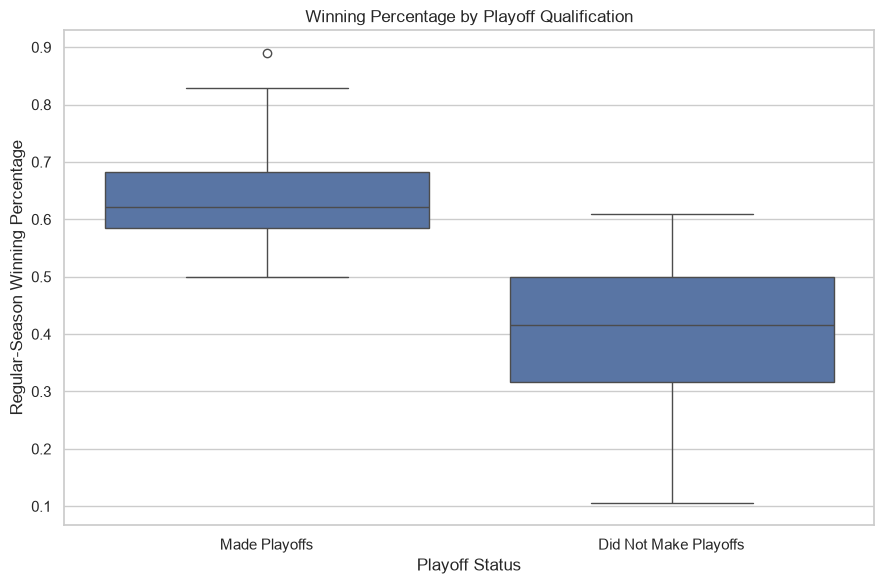

In [96]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Playoff_Status",
    y="Win_Pct"
)

plt.title(
    "Winning Percentage by Playoff Qualification"
)

plt.xlabel(
    "Playoff Status"
)

plt.ylabel(
    "Regular-Season Winning Percentage"
)

plt.tight_layout()

plt.savefig(
    "winning_percentage_playoffs.png",
    dpi=300
)

plt.show()

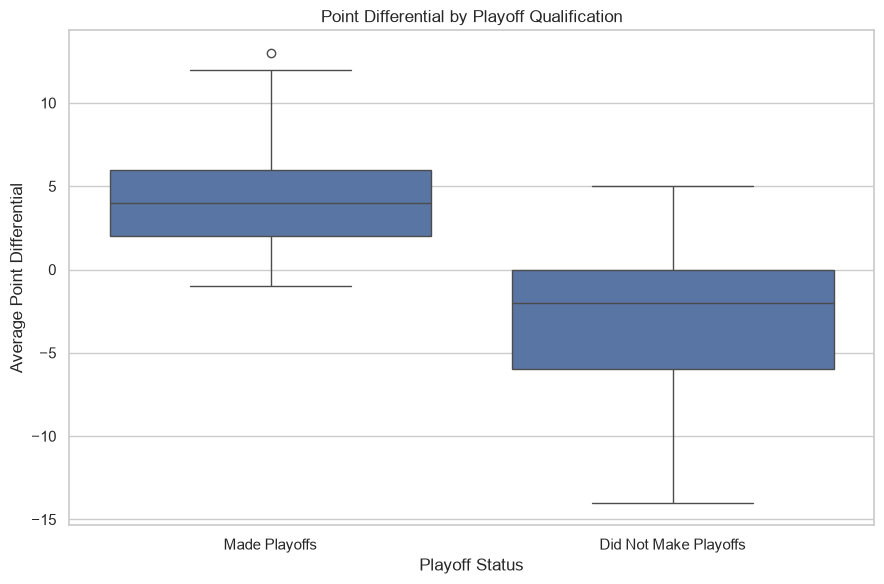

In [97]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Playoff_Status",
    y="Point_Diff"
)

plt.title(
    "Point Differential by Playoff Qualification"
)

plt.xlabel(
    "Playoff Status"
)

plt.ylabel(
    "Average Point Differential"
)

plt.tight_layout()

plt.show()

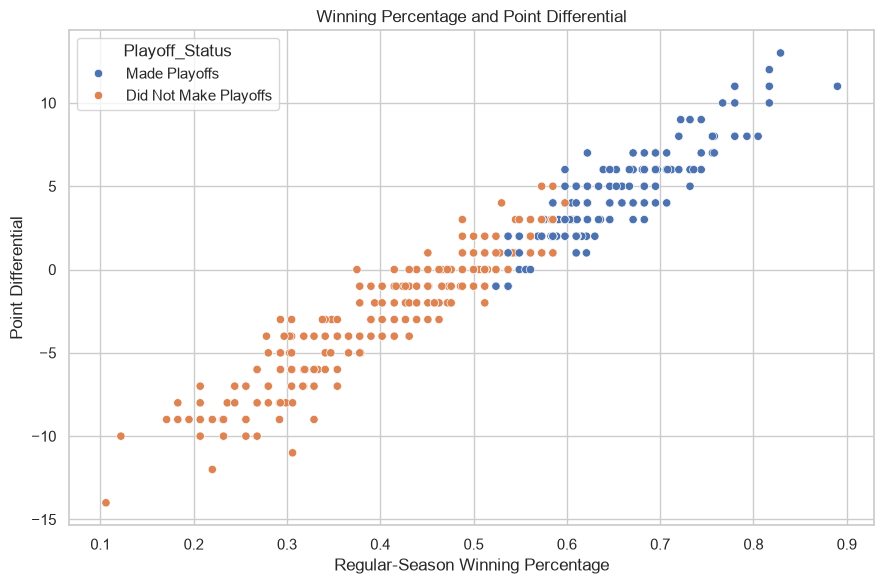

In [98]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Win_Pct",
    y="Point_Diff",
    hue="Playoff_Status"
)

plt.title(
    "Winning Percentage and Point Differential"
)

plt.xlabel(
    "Regular-Season Winning Percentage"
)

plt.ylabel(
    "Point Differential"
)

plt.tight_layout()

plt.show()

there are some of the anomalies with very high winning precentage and also some high winniing precentages that still didnt make the playoffs 

In [99]:
predictions = model.predict(X_test)

probabilities = model.predict_proba(
    X_test
)[:, 1]

In [100]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "Accuracy:",
    round(accuracy, 3)
)

Accuracy: 0.878


In [101]:
print(
    classification_report(
        y_test,
        predictions,
        target_names=[
            "Did Not Make Playoffs",
            "Made Playoffs"
        ]
    )
)

                       precision    recall  f1-score   support

Did Not Make Playoffs       0.91      0.89      0.90        54
        Made Playoffs       0.84      0.86      0.85        36

             accuracy                           0.88        90
            macro avg       0.87      0.88      0.87        90
         weighted avg       0.88      0.88      0.88        90



In [102]:
summary = df.groupby(
    "Playoff_Status"
)[
    [
        "Win_Pct",
        "Point_Diff",
        "Points_PG",
        "Opp_Points_PG"
    ]
].mean()

summary

,Win_Pct,Point_Diff,Points_PG,Opp_Points_PG
Playoff_Status,,,,
Did Not Make Playoffs,0.406219,-2.785185,105.229630,108.033333
Made Playoffs,0.639811,4.144444,108.483333,104.238889


Ethics 
This project uses publicly available NBA team statistics obtained through an
API. The data are aggregated at the team-season level and do not contain
personally identifying information. API requests were limited to the seasons
needed for this project, and a one-second delay was used between requests to
avoid excessive requests.

Limitations
The dataset also does not include every factor that could affect playoff
qualification. Injuries, trades, player availability, coaching changes,
strength of schedule, team chemistry, and individual player performance are
not fully represented.

AI Transparency
I used AI to help me find an API, help with understanding and writing code, troubleshoot some of the problems with my code and visualizations.

Refrences
NBA API. (n.d.). *LeagueStandings endpoint documentation*.
https://github.com/swar/nba_api